<center><img src="images/clothing.jpg"></center>

# Clothing Reviews – Embeddings + ChromaDB Showcase

Welcome to the world of e-commerce, where customer feedback is a goldmine of insights!

In this project, we use OpenAI text embeddings and ChromaDB to:
- Embed women's clothing reviews
- Visualize them in 2D
- Categorize them into themes (Quality, Fit, Style, Comfort)
- Store them in ChromaDB with rich metadata
- Run semantic search with filters
- Do simple RAG-style Q&A over the reviews


## The Data

You will be working with a dataset specifically focusing on customer reviews. Below is the data dictionary for the relevant field:

## womens_clothing_e-commerce_reviews.csv

| Column        | Description                           |
|---------------|---------------------------------------|
| `'Review Text'` | Textual feedback provided by customers about their shopping experience and product quality. |

Armed with access to powerful embedding API services, you will process the reviews, extract meaningful insights, and present your findings.

Let's get started!

## Install useful libraries

In [29]:
from importlib.metadata import version

# Run this cell to install ChromaDB if desired
try:
    assert version('chromadb') == '0.4.17'
except:
    !pip install chromadb==0.4.17

try:
    assert version('pysqlite3') == '0.5.2'
except:
    !pip install pysqlite3-binary==0.5.2

__import__('pysqlite3')
import sys
sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


## Load the dataset
Load data and perform basic data checks to ensure you are using relevant data for the analysis

In [30]:
# Load the dataset
reviews = pd.read_csv("womens_clothing_e-commerce_reviews.csv")

# Basic cleaning: keep only non-null Review Text
reviews = reviews.dropna(subset=["Review Text"]).reset_index(drop=True)

reviews[["Review Text", "Rating", "Age", "Department Name", "Class Name"]].head()


,Review Text,Rating,Age,Department Name,Class Name
0,Absolutely wonderful - silky and sexy and comf...,4,33,Intimate,Intimates
1,Love this dress! it's sooo pretty. i happene...,5,34,Dresses,Dresses
2,I had such high hopes for this dress and reall...,3,60,Dresses,Dresses
3,"I love, love, love this jumpsuit. it's fun, fl...",5,50,Bottoms,Pants
4,This shirt is very flattering to all due to th...,5,47,Tops,Blouses


In [36]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial import distance
from textwrap import shorten
from collections import deque

import chromadb
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

from openai import OpenAI  # new OpenAI SDK

# ---- OpenAI setup ----
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
assert OPENAI_API_KEY, "Set OPENAI_API_KEY in your environment"

client_oa = OpenAI(api_key=OPENAI_API_KEY)
EMBEDDING_MODEL = "text-embedding-3-small"
CHAT_MODEL = "gpt-4.1-mini"


In [32]:
# Extract texts
review_texts = reviews["Review Text"].tolist()

def get_embeddings(texts, model=EMBEDDING_MODEL, batch_size=256):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        resp = client_oa.embeddings.create(input=batch, model=model)
        all_embs.extend([d.embedding for d in resp.data])
    return np.array(all_embs, dtype=np.float32)

embeddings = get_embeddings(review_texts)
embeddings.shape


(958, 1536)

## Topic categorization (Quality / Fit / Style / Comfort)


In [33]:
# Define topics
categories = ["Quality", "Fit", "Style", "Comfort"]

# Embeddings for category labels
cat_resp = client_oa.embeddings.create(input=categories, model=EMBEDDING_MODEL)
category_embeddings = np.array([d.embedding for d in cat_resp.data], dtype=np.float32)

def categorize_feedback(text_embedding, category_embeddings, categories):
    sims = [
        {"distance": distance.cosine(text_embedding, cat_emb), "index": i}
        for i, cat_emb in enumerate(category_embeddings)
    ]
    # Choose category with MIN cosine distance
    closest = min(sims, key=lambda x: x["distance"])
    return categories[closest["index"]]

feedback_categories = [
    categorize_feedback(emb, category_embeddings, categories)
    for emb in embeddings
]

reviews["Topic"] = feedback_categories
reviews["Topic"].value_counts()


Topic
Fit        666
Style      214
Comfort     65
Quality     13
Name: count, dtype: int64

## t‑SNE visualization by topic

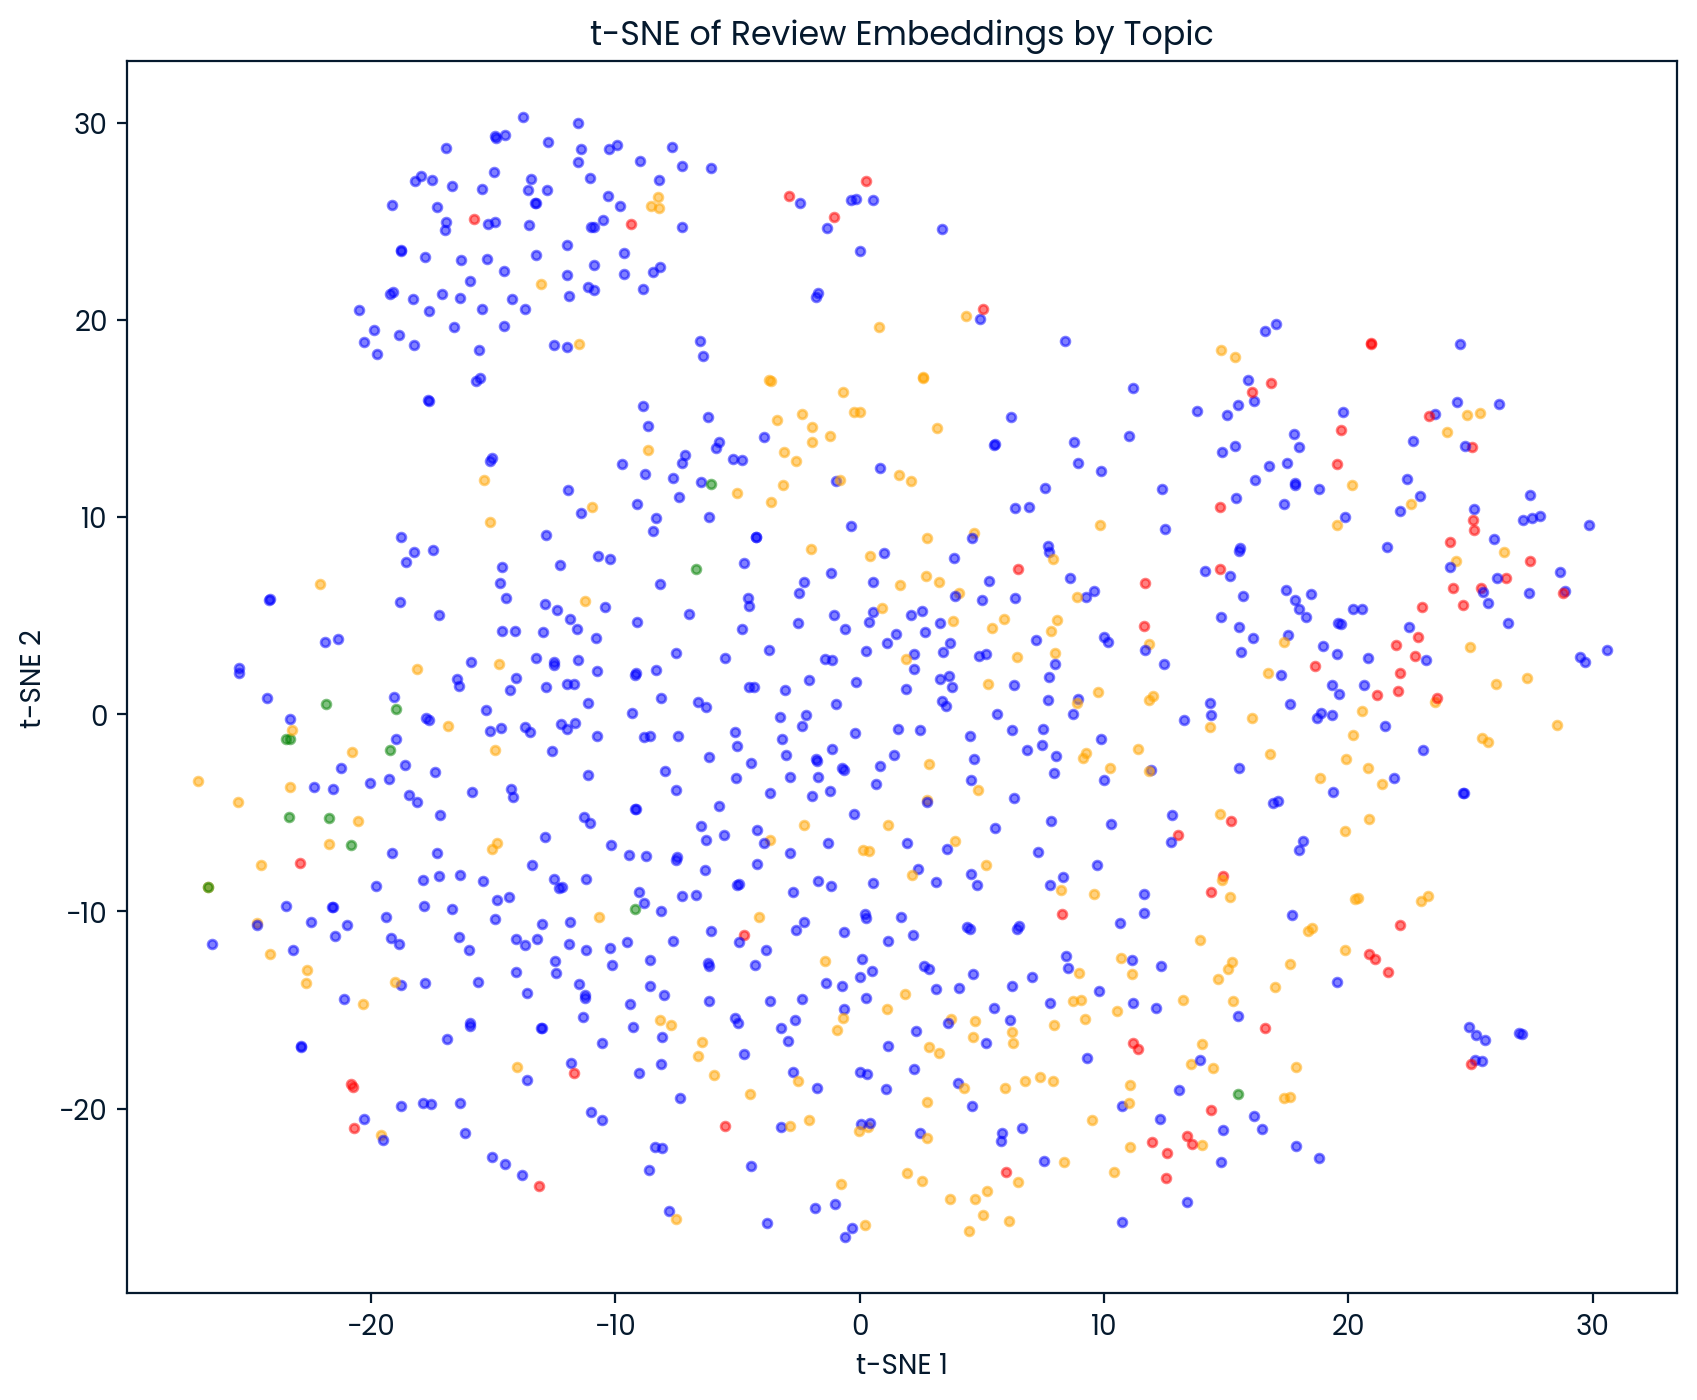

In [34]:
def apply_tsne(vectors, random_state=0):
    tsne = TSNE(
        n_components=2,
        random_state=random_state,
        perplexity=40,
        init="random",
        learning_rate="auto",
    )
    return tsne.fit_transform(vectors)

embeddings_2d = apply_tsne(embeddings)

def plot_tsne(tsne_results, labels):
    plt.figure(figsize=(10, 8))
    topics = sorted(set(labels))
    colors = {t: c for t, c in zip(topics, ["red", "blue", "green", "orange"])}
    for (x, y), topic in zip(tsne_results, labels):
        plt.scatter(x, y, c=colors[topic], alpha=0.5, s=10)
    plt.title("t-SNE of Review Embeddings by Topic")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()

plot_tsne(embeddings_2d, reviews["Topic"].tolist())


## ChromaDB: main collection with metadata

In [39]:
# Persistent Chroma client
chroma_client = chromadb.PersistentClient(path="chroma_reviews_db")

openai_ef = OpenAIEmbeddingFunction(
    model_name=EMBEDDING_MODEL,
    api_key=OPENAI_API_KEY,
)

# Main collection
collection = chroma_client.get_or_create_collection(
    name="review_embeddings",
    embedding_function=openai_ef,
)

# Build metadata for each review
metadata = []
for _, row in reviews.iterrows():
    meta = {
        "rating": int(row.get("Rating", 0)),
        "age": int(row.get("Age", 0)) if not np.isnan(row.get("Age", np.nan)) else -1,
        "topic": row.get("Topic", "Unknown"),
        "department": str(row.get("Department Name", "")),
        "class_name": str(row.get("Class Name", "")),
    }
    metadata.append(meta)

# Add to Chroma (Chroma computes embeddings using embedding_function)
collection.add(
    ids=[str(i) for i in range(len(reviews))],
    documents=review_texts,
    metadatas=metadata,
)

collection.count()

958

## Extra Chroma collections: positive vs negative

In [40]:
# Separate collections for positive vs non-positive reviews
pos_collection = chroma_client.get_or_create_collection(
    name="reviews_positive",
    embedding_function=openai_ef,
)
neg_collection = chroma_client.get_or_create_collection(
    name="reviews_negative",
    embedding_function=openai_ef,
)

pos_ids, pos_docs, pos_meta = [], [], []
neg_ids, neg_docs, neg_meta = [], [], []

for i, row in reviews.iterrows():
    meta = {
        "rating": int(row["Rating"]),
        "age": int(row["Age"]) if not np.isnan(row["Age"]) else -1,
        "topic": row["Topic"],
        "department": str(row.get("Department Name", "")),
    }
    if row["Rating"] >= 4:
        pos_ids.append(str(i))
        pos_docs.append(row["Review Text"])
        pos_meta.append(meta)
    else:
        neg_ids.append(str(i))
        neg_docs.append(row["Review Text"])
        neg_meta.append(meta)

if pos_ids:
    pos_collection.add(ids=pos_ids, documents=pos_docs, metadatas=pos_meta)
if neg_ids:
    neg_collection.add(ids=neg_ids, documents=neg_docs, metadatas=neg_meta)

print("Positive:", pos_collection.count(), "Negative:", neg_collection.count())


Positive: 737 Negative: 221


## Generic similarity search helper (with filters)

In [41]:
def find_similar_reviews(input_text, coll, n=5, where=None):
    res = coll.query(
        query_texts=[input_text],
        n_results=n,
        where=where or {},
    )
    docs = res["documents"][0]
    metas = res["metadatas"][0]
    dists = res.get("distances", [[None]])[0]
    out = []
    for d, m, dist in zip(docs, metas, dists):
        out.append({"text": d, "meta": m, "dist": dist})
    return out

# Example
example_review = "Absolutely wonderful - silky and sexy and comfortable"
similar = find_similar_reviews(example_review, collection, n=3)

for r in similar:
    print("Rating:", r["meta"]["rating"], "| Topic:", r["meta"]["topic"])
    print(r["text"])
    print("-" * 80)


Rating: 4 | Topic: Comfort
Absolutely wonderful - silky and sexy and comfortable
--------------------------------------------------------------------------------
Rating: 5 | Topic: Comfort
Very comfortable and versatile. got lots of compliments.
--------------------------------------------------------------------------------
Rating: 4 | Topic: Fit
This is a very comfortable and sexy sleep dress, the way it drapes. i can see that the type of fabric is not suitable for out and about activities and can catch on snags, etc. very easily. once i relegated it to the nightgown category it became my favorite item to wear and lounge in.
--------------------------------------------------------------------------------


## Analytics using Chroma metadata (e.g., top departments)

In [ ]:
def top_departments_for_topic(topic, coll, min_rating=0, n=50):
    res = coll.query(
        query_texts=[topic],
        n_results=n,
        where={"rating": {"$gte": min_rating}, "topic": topic},
    )
    metas = res["metadatas"][0]
    depts = pd.Series([m["department"] for m in metas if m.get("department")]).value_counts()
    return depts

print("Top departments for Comfort (rating >= 4):")
top_departments_for_topic("Comfort", collection, min_rating=4, n=100)


In [42]:
class ReviewSearchSession:
    def __init__(self, coll, history_size=5):
        self.collection = coll
        self.history = deque(maxlen=history_size)
    
    def search(self, query, n=5, where=None):
        res = self.collection.query(
            query_texts=[query],
            n_results=n,
            where=where or {},
        )
        docs = res["documents"][0]
        metas = res["metadatas"][0]
        dists = res.get("distances", [[None]])[0]
        results = [
            {"text": d, "meta": m, "dist": dist}
            for d, m, dist in zip(docs, metas, dists)
        ]
        self.history.append({"query": query, "results": results})
        return results
    
    def last_queries(self):
        return list(self.history)

session = ReviewSearchSession(collection)

res1 = session.search("scratchy fabric", n=3)
res2 = session.search("itchy and uncomfortable", n=3, where={"rating": {"$lte": 3}})

session.last_queries()


[{'query': 'scratchy fabric',
  'results': [{'text': 'The sweater is cute, but scratchy.',
    'meta': {'age': 37,
     'class_name': 'Sweaters',
     'department': 'Tops',
     'rating': 3,
     'topic': 'Fit'},
    'dist': 0.9091904759407043},
   {'text': 'The title says it all....this fabric of this top is both the best and worst part of the design. the colors are vibrant and the combination of materials (shoulder is a knit, sweater-like navy fabric) is interesting. however, that is where the positive comments end on this one. the top is so scratchy,, stiff, and, frankly, uncomfortable. i cannot imagine wanting to wear it. it could benefit from a lining, and that might have solved the problem of scratchy, itchy fabric.\n\nthe stiff fabric of the bo',
    'meta': {'age': 52,
     'class_name': 'Blouses',
     'department': 'Tops',
     'rating': 1,
     'topic': 'Fit'},
    'dist': 0.9418463706970215},
   {'text': "3 tags sewn in, 2 small (about 1'' long) and 1 huge (about 2'' x 3'')

In [43]:
def service_query_reviews(
    question: str,
    sentiment: str | None = None,
    topic: str | None = None,
    k: int = 5,
):
    # choose collection based on sentiment
    coll = collection
    if sentiment == "positive":
        coll = pos_collection
    elif sentiment == "negative":
        coll = neg_collection
    
    where = {}
    if topic:
        where["topic"] = topic
    
    res = coll.query(
        query_texts=[question],
        n_results=k,
        where=where,
    )
    docs = res["documents"][0]
    metas = res["metadatas"][0]
    return [{"text": d, "meta": m} for d, m in zip(docs, metas)]

examples = [
    ("What do people like about the fit?", "positive", "Fit"),
    ("What do people complain about regarding quality?", "negative", "Quality"),
]

for q, s, t in examples:
    print(f"\n=== Q: {q} | sentiment={s}, topic={t} ===")
    for r in service_query_reviews(q, sentiment=s, topic=t, k=3):
        print("Rating:", r["meta"]["rating"], "| Dept:", r["meta"]["department"])
        print(r["text"])
        print("-" * 60)



=== Q: What do people like about the fit? | sentiment=positive, topic=Fit ===
Rating: 5 | Dept: Intimate
Received many compliments the first day i wore them.. amazing fit. disagree with the other post. the
quality is amazing. i wish they had other colors. bought xs
------------------------------------------------------------
Rating: 5 | Dept: Jackets
The jacket is great, the quality is very good and the fit too, the best part is how it looks !
------------------------------------------------------------
Rating: 4 | Dept: Bottoms
But i thought this was lace or with texture, it is more a pattern on regular fabric.

colors are nice, there are subtle flowers with bright colors in the pattern, the fit is nice, the 0p fit snugly enough, i don't think there was much give but that was comfortable enough. petite length did end below the knee as shown. i think it would have been nicer shorter but don't want to have to pay extra to ehm so i left that one behind...maybe on sale :-)
--------------

# t‑SNE + Chroma: highlight neighbors on the plot

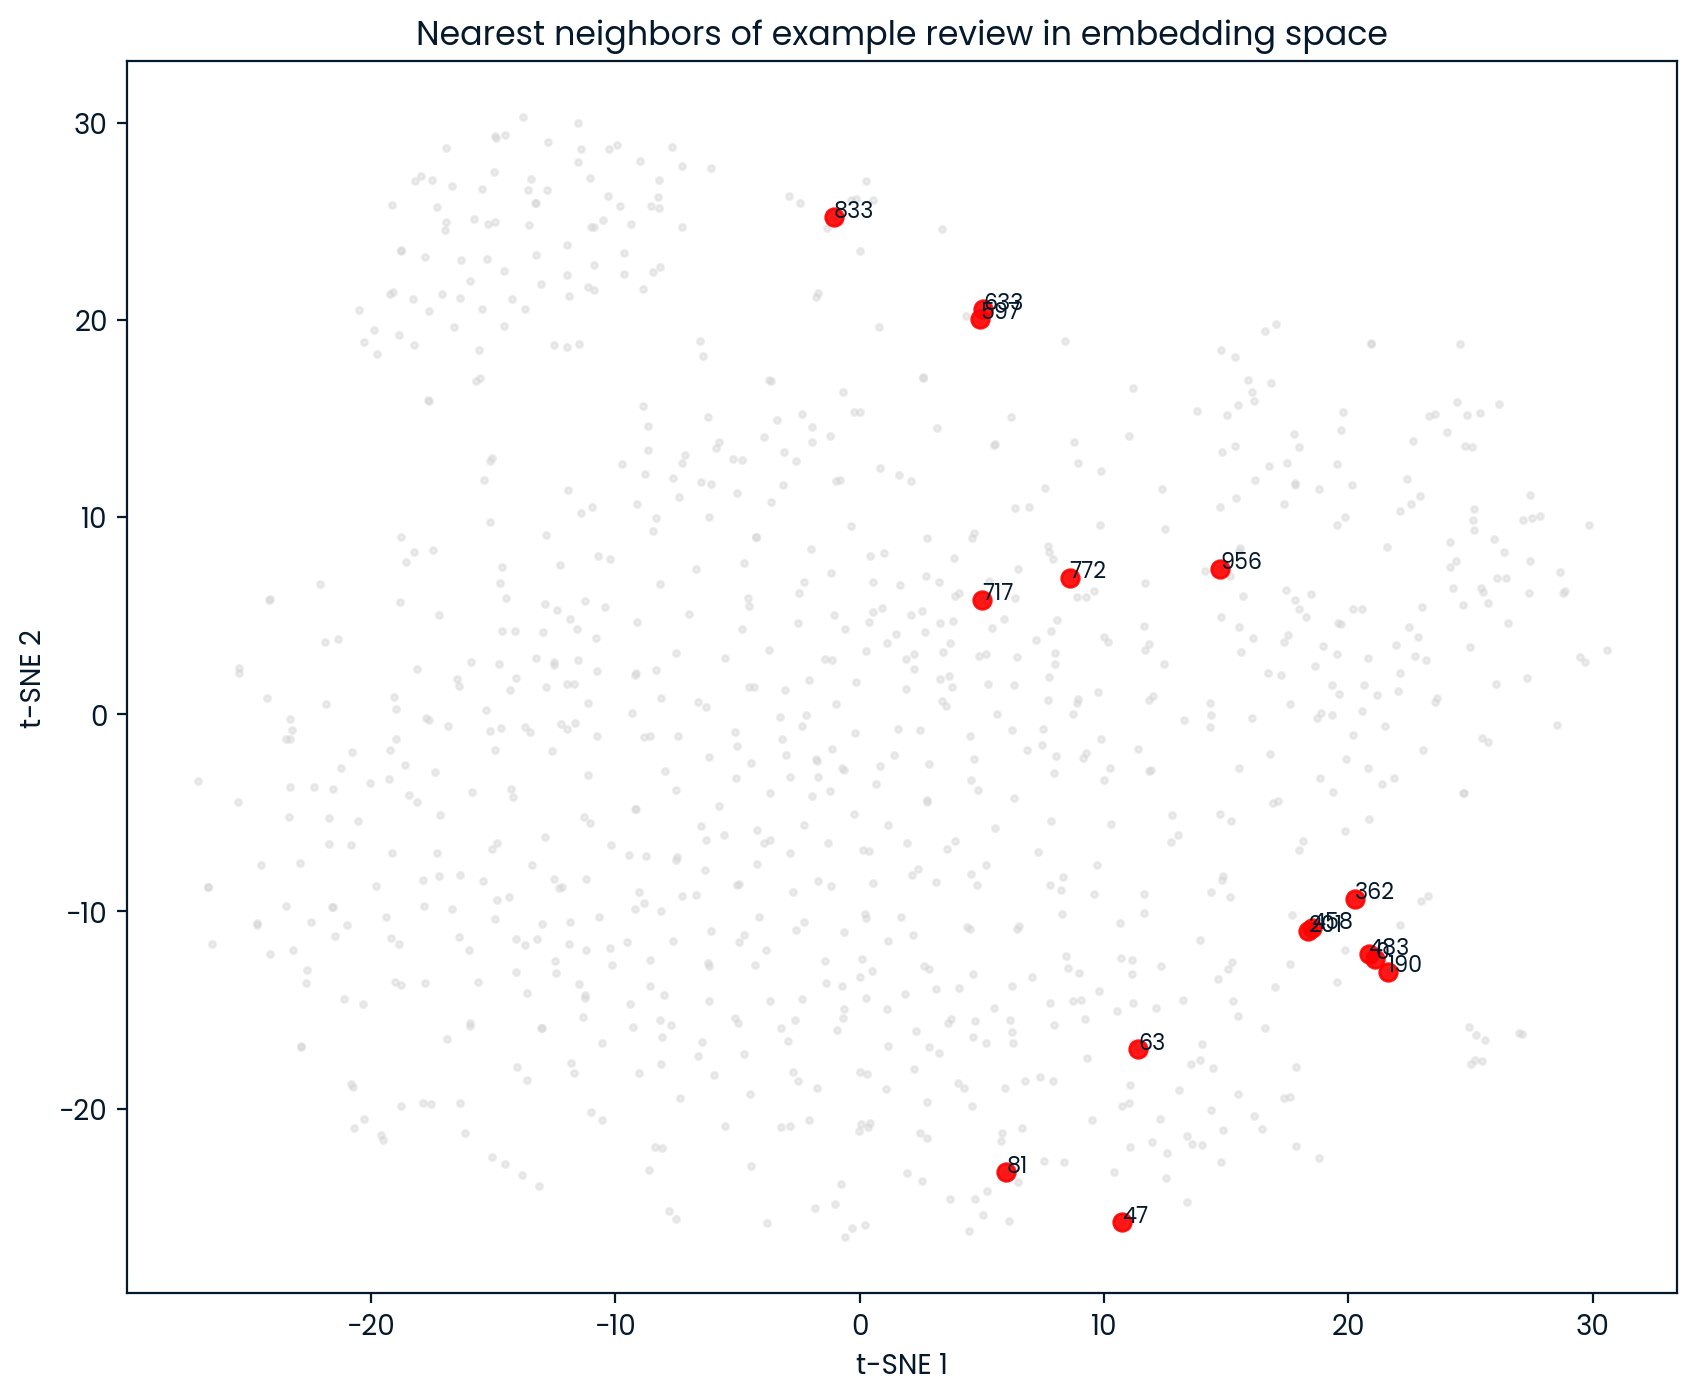

In [44]:
# Map index -> 2D coords
coords = {i: (x, y) for i, (x, y) in enumerate(embeddings_2d)}

def highlight_neighbors(example_text, coll, n=10):
    res = coll.query(query_texts=[example_text], n_results=n)
    ids = [int(_id) for _id in res["ids"][0]]
    
    plt.figure(figsize=(10, 8))
    # all points light
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c="lightgray", s=5, alpha=0.4)
    
    # highlight neighbors
    xs = [coords[i][0] for i in ids]
    ys = [coords[i][1] for i in ids]
    plt.scatter(xs, ys, c="red", s=40, alpha=0.9)
    for i, (x, y) in zip(ids, zip(xs, ys)):
        plt.text(x, y, str(i), fontsize=8)
    
    plt.title("Nearest neighbors of example review in embedding space")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()

highlight_neighbors("Absolutely wonderful - silky and sexy and comfortable", collection, n=15)


# RAG‑style Q&A over reviews (Chroma + GPT)

In [46]:
# from textwrap import shorten

# # Set the supported model name
# CHAT_MODEL = "gpt-3.5-turbo"  # or another from the supported list

# def ask_reviews_question(question, coll, k=10):
#     # Retrieve relevant reviews
#     res = coll.query(
#         query_texts=[question],
#         n_results=k,
#     )
#     docs = res["documents"][0]
#     context = "\n\n".join(shorten(d, width=400, placeholder="...") for d in docs)

#     system_msg = (
#         "You are an assistant summarizing customer clothing reviews. "
#         "Answer based ONLY on the provided reviews. "
#         "Highlight common themes and avoid making up facts."
#     )

#     completion = client_oa.chat.completions.create(
#         model=CHAT_MODEL,
#         messages=[
#             {"role": "system", "content": system_msg},
#             {"role": "user", "content": f"Question: {question}\n\nReviews:\n{context}"},
#         ],
#         temperature=0.2,
#     )
#     return completion.choices[0].message.content

# question = "What do customers most often complain about regarding dress fit?"
# answer = ask_reviews_question(question, collection, k=15)
# print(answer)

Customers most often complain about dress fit issues related to the chest area being too small for larger chests, hips fitting awkwardly, dresses being too big or loose in certain areas, and sizing inconsistencies. Some customers also mentioned issues with the length, waist placement, and overall proportion of the dress not being flattering.


In [49]:
def ask_reviews_question_advanced(
    question: str,
    coll,
    k: int = 10,
    topic: str | None = None,
    sentiment: str | None = None,  # "positive" / "negative" / None
):
    # -------- 1. Choose collection based on sentiment --------
    _coll = coll
    if sentiment == "positive":
        _coll = pos_collection
    elif sentiment == "negative":
        _coll = neg_collection

    # -------- 2. Build metadata filter --------
    where = {}
    if topic:
        where["topic"] = topic

    # -------- 3. Retrieve context from Chroma --------
    res = _coll.query(
        query_texts=[question],
        n_results=k,
        where=where,
    )
    docs = res["documents"][0]
    metas = res["metadatas"][0]

    # If we got nothing, bail out early
    if not docs:
        return {
            "answer": "I could not find any reviews matching this question and filters.",
            "supporting_reviews": [],
            "hallucination_flag": True,
        }

    # Build context for the LLM
    from textwrap import shorten
    context_blocks = []
    for d, m in zip(docs, metas):
        meta_str = f"Rating: {m.get('rating')}, Topic: {m.get('topic')}, Dept: {m.get('department')}"
        context_blocks.append(meta_str + "\n" + shorten(d, width=400, placeholder="..."))
    context = "\n\n---\n\n".join(context_blocks)

    system_msg = (
        "You are an assistant summarizing customer clothing reviews. "
        "Answer based ONLY on the provided reviews. "
        "Cite concrete patterns from the text and do NOT invent details."
    )

    user_msg = (
        f"Question: {question}\n\n"
        "Here are relevant reviews:\n\n"
        f"{context}\n\n"
        "Answer the question using only these reviews."
    )

    completion = client_oa.chat.completions.create(
        model=CHAT_MODEL,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg},
        ],
        temperature=0.2,
    )
    answer = completion.choices[0].message.content

    # -------- 4. Very simple hallucination guard --------
    # Check how many important words from the answer appear in the context
    import re
    def tokenize(text):
        return set(re.findall(r"[a-zA-Z]{4,}", text.lower()))

    ctx_tokens = tokenize(context)
    ans_tokens = tokenize(answer)

    # Focus on non-stopwords-ish by length only (simple heuristic)
    overlap = ans_tokens & ctx_tokens
    overlap_ratio = len(overlap) / max(len(ans_tokens), 1)

    hallucination_flag = overlap_ratio < 0.25  # threshold you can tune

    return {
        "answer": answer,
        "supporting_reviews": [
            {"text": d, "meta": m} for d, m in zip(docs, metas)
        ],
        "hallucination_flag": hallucination_flag,
        "overlap_ratio": overlap_ratio,
    }


In [50]:
# 1) General question, no filters
res_general = ask_reviews_question_advanced(
    "What do customers complain about regarding dress fit?",
    collection,
    k=15,
)
print("ANSWER:\n", res_general["answer"])
print("\nHallucination flag:", res_general["hallucination_flag"], "overlap:", res_general["overlap_ratio"])

# 2) Only negative, topic = Fit
res_negative_fit = ask_reviews_question_advanced(
    "What issues do they report with fit?",
    collection,
    k=15,
    topic="Fit",
    sentiment="negative",
)
print("\n\n=== NEGATIVE + FIT ONLY ===")
print("ANSWER:\n", res_negative_fit["answer"])
print("\nHallucination flag:", res_negative_fit["hallucination_flag"], "overlap:", res_negative_fit["overlap_ratio"])

# Inspect first 3 supporting reviews
for r in res_negative_fit["supporting_reviews"][:3]:
    print("\n--- Review ---")
    print("Rating:", r["meta"]["rating"], "| Topic:", r["meta"]["topic"], "| Dept:", r["meta"].get("department"))
    print(r["text"])


ANSWER:
 Customers complain about dresses being too big in certain areas, such as the chest, waist, or hips, leading to an unflattering fit. Some mention issues with the top being too large while the bottom fits well, or the waist hitting too high. Sizing inconsistencies are also noted, with some customers having to size up or down based on reviews.

Hallucination flag: False overlap: 0.6060606060606061


=== NEGATIVE + FIT ONLY ===
ANSWER:
 Customers report various fit issues with the clothing items. Some mention odd cuts, strange fits, tightness even after sizing up, fabric not falling correctly, sleeves being too short, tops being too small in the upper arms/shoulder area, and pants hitting at awkward points on the body. Additionally, there are complaints about the fit not matching the website, exposing undergarments when lifting arms, and items being too big or not secure enough.

Hallucination flag: False overlap: 0.4888888888888889

--- Review ---
Rating: 3 | Topic: Fit | Dept: D